# Geneformer-V2-104M fine-tune vs from-scratch on PBMC

Companion to `2026-04-22_14-31_compute_finetune_pretrained_geneformer_pbmc_noise_scaling.py`.
Compares (a) a 3-epoch continued-MLM fine-tune of the pretrained Geneformer-V2-104M against (b) the from-scratch small Geneformer baseline already produced by the PBMC full sweep.

Both runs share the PBMC 10-size x 10-quality grid and the same MI signals (`celltype.l3`, `protein_counts`). Layout mirrors `2026-04-21_14-00_plotting_finetune_pretrained_state_pbmc_noise_scaling.ipynb`.

In [ ]:
# Collect loss curves + MI for BOTH:
#   * fine-tune (Geneformer-V2-104M) under ~/noise_scaling/data/other/model_sizing/geneformer/finetune_00/<size>/<quality>/
#   * from-scratch small Geneformer under ~/noise_scaling/data/PBMC/<size>/<quality>/results/Geneformer/model/
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

FT_ROOT   = Path('/home/igor/noise_scaling/data/other/model_sizing/geneformer/finetune_00')
SC_ROOT   = Path('/home/igor/noise_scaling/data/PBMC')
MI_SEED   = 42
SIGNAL_RE = re.compile(r'Y_(.+?)(?:_[0-9][0-9_.e\-]*)?(?:_geneformer)?$')


def _read_metrics(metrics_csv: Path):
    """Return (train_df[step,train_loss], val_df[step,val_loss]) or (None, None).
    Supports both the Lightning ``metrics.csv`` from-scratch runs and the HF
    Trainer ``log_history``-derived ``metrics.csv`` written by our fine-tune script.
    """
    if not metrics_csv.exists() or metrics_csv.stat().st_size == 0:
        return None, None
    try:
        m = pd.read_csv(metrics_csv, on_bad_lines='skip')
    except Exception:
        return None, None

    # HF Trainer log_history -> columns: {'loss','learning_rate','epoch','step'} or {'eval_loss',...}
    tr = va = None
    if 'loss' in m.columns:
        tr = (m.dropna(subset=['loss'])[['step','loss']]
                .rename(columns={'loss':'train_loss'}).sort_values('step').reset_index(drop=True))
    if 'eval_loss' in m.columns:
        va = (m.dropna(subset=['eval_loss'])[['step','eval_loss']]
                .rename(columns={'eval_loss':'val_loss'}).sort_values('step').reset_index(drop=True))

    # Lightning RobustCSVLogger
    if tr is None and 'trainer/train_loss' in m.columns:
        tr = (m.dropna(subset=['trainer/train_loss'])[['step','trainer/train_loss']]
                .rename(columns={'trainer/train_loss':'train_loss'}).sort_values('step').reset_index(drop=True))
    if va is None and 'validation/val_loss' in m.columns:
        va = (m.dropna(subset=['validation/val_loss'])[['step','validation/val_loss']]
                .rename(columns={'validation/val_loss':'val_loss'}).sort_values('step').reset_index(drop=True))
    return tr, va


def _ft_metrics(size, quality):
    q_dir = FT_ROOT / str(size) / str(quality)
    m = q_dir / 'trainer_logs' / 'metrics.csv'
    if m.exists():
        return _read_metrics(m)
    # Fallback: some HF Trainer runs write to runs/<timestamp>/ — scan.
    for cand in sorted(q_dir.glob('trainer_logs/**/metrics.csv')):
        return _read_metrics(cand)
    return None, None


def _sc_metrics(size, quality):
    base = SC_ROOT / str(size) / str(quality) / 'results' / 'Geneformer' / 'model'
    for cand in sorted(base.glob('runs/**/trainer_state.json')):
        try:
            hist = pd.DataFrame(json.loads(cand.read_text())['log_history'])
            tr = va = None
            if 'loss' in hist.columns:
                tr = (hist.dropna(subset=['loss'])[['step','loss']]
                        .rename(columns={'loss':'train_loss'}).sort_values('step').reset_index(drop=True))
            if 'eval_loss' in hist.columns:
                va = (hist.dropna(subset=['eval_loss'])[['step','eval_loss']]
                        .rename(columns={'eval_loss':'val_loss'}).sort_values('step').reset_index(drop=True))
            return tr, va
        except Exception:
            continue
    m = base / 'loss' / 'metrics.csv'
    if m.exists():
        return _read_metrics(m)
    return None, None


def _mi_ft(mi_root: Path):
    """New-style per-cell MI layout: MI/<seed>/Y_<signal>/lmi_mutual_information.txt"""
    out = {}
    if not mi_root.is_dir():
        return out
    for sig_dir in mi_root.iterdir():
        if not sig_dir.is_dir():
            continue
        m = SIGNAL_RE.match(sig_dir.name)
        signal = m.group(1) if m else sig_dir.name.replace('Y_', '')
        f = sig_dir / 'lmi_mutual_information.txt'
        if f.exists():
            try:
                out[signal] = float(f.read_text().strip())
            except ValueError:
                pass
    return out


def _mi_sc(mi_root: Path, quality: float):
    """From-scratch MI layout: MI/<seed>/Y_<signal>_<quality>_geneformer/lmi_mutual_information.txt"""
    out = {}
    if not mi_root.is_dir():
        return out
    for sig_dir in mi_root.iterdir():
        if not sig_dir.is_dir():
            continue
        m = SIGNAL_RE.match(sig_dir.name)
        signal = m.group(1) if m else sig_dir.name
        f = sig_dir / 'lmi_mutual_information.txt'
        if f.exists():
            try:
                out[signal] = float(f.read_text().strip())
            except ValueError:
                pass
    return out


rows = []
CURVES_FT = {}   # (size, quality) -> (train_df, val_df)
CURVES_SC = {}

# If the fine-tune sweep root exists, use whatever sizes are materialised.
sizes = sorted({int(p.name) for p in FT_ROOT.iterdir() if p.is_dir() and p.name.isdigit()}) if FT_ROOT.is_dir() else []
if not sizes:
    sizes = [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000]
qualities_all = [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422,
                 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0]

for size in sizes:
    for quality in qualities_all:
        ft_tr, ft_va = _ft_metrics(size, quality)
        sc_tr, sc_va = _sc_metrics(size, quality)
        CURVES_FT[(size, quality)] = (ft_tr, ft_va)
        CURVES_SC[(size, quality)] = (sc_tr, sc_va)

        ft_mi = _mi_ft(FT_ROOT / str(size) / str(quality) / 'MI' / str(MI_SEED))
        sc_mi = _mi_sc(SC_ROOT / str(size) / str(quality) / 'results' / 'Geneformer' / 'model' / 'MI' / str(MI_SEED), quality)
        row = {'size': size, 'quality': quality}
        for s, v in ft_mi.items():
            row[f'ft_mi_{s}'] = v
        for s, v in sc_mi.items():
            row[f'sc_mi_{s}'] = v
        rows.append(row)

df = pd.DataFrame(rows).sort_values(['size', 'quality']).reset_index(drop=True)
mi_signals = sorted({c.split('_', 2)[2] for c in df.columns if c.startswith(('ft_mi_', 'sc_mi_'))})
print(f'{len(df)} cells   signals={mi_signals}   sizes={sizes}')
df.head()

In [2]:
# Which (size, quality) cells have curves / MI on disk.
ft_tr_have = {k for k, (t, v) in CURVES_FT.items() if t is not None and len(t)}
ft_va_have = {k for k, (t, v) in CURVES_FT.items() if v is not None and len(v)}
sc_tr_have = {k for k, (t, v) in CURVES_SC.items() if t is not None and len(t)}
sc_va_have = {k for k, (t, v) in CURVES_SC.items() if v is not None and len(v)}
print(f'fine-tune   : train={len(ft_tr_have)}/{len(CURVES_FT)}   val={len(ft_va_have)}/{len(CURVES_FT)}')
print(f'from-scratch: train={len(sc_tr_have)}/{len(CURVES_SC)}   val={len(sc_va_have)}/{len(CURVES_SC)}')

fine-tune   : train=0/100   val=0/100
from-scratch: train=0/100   val=0/100


## Train / validation loss — fine-tune vs from-scratch

One row per **quality**, two columns (train, val). Both axes are pinned to shared limits (global min/max across both regimes) so fine-tune's short MLM curve and the multi-epoch from-scratch curve can be visually compared without per-panel rescaling.

Fine-tune is plotted at the largest available dataset size; from-scratch is matched to the same size.

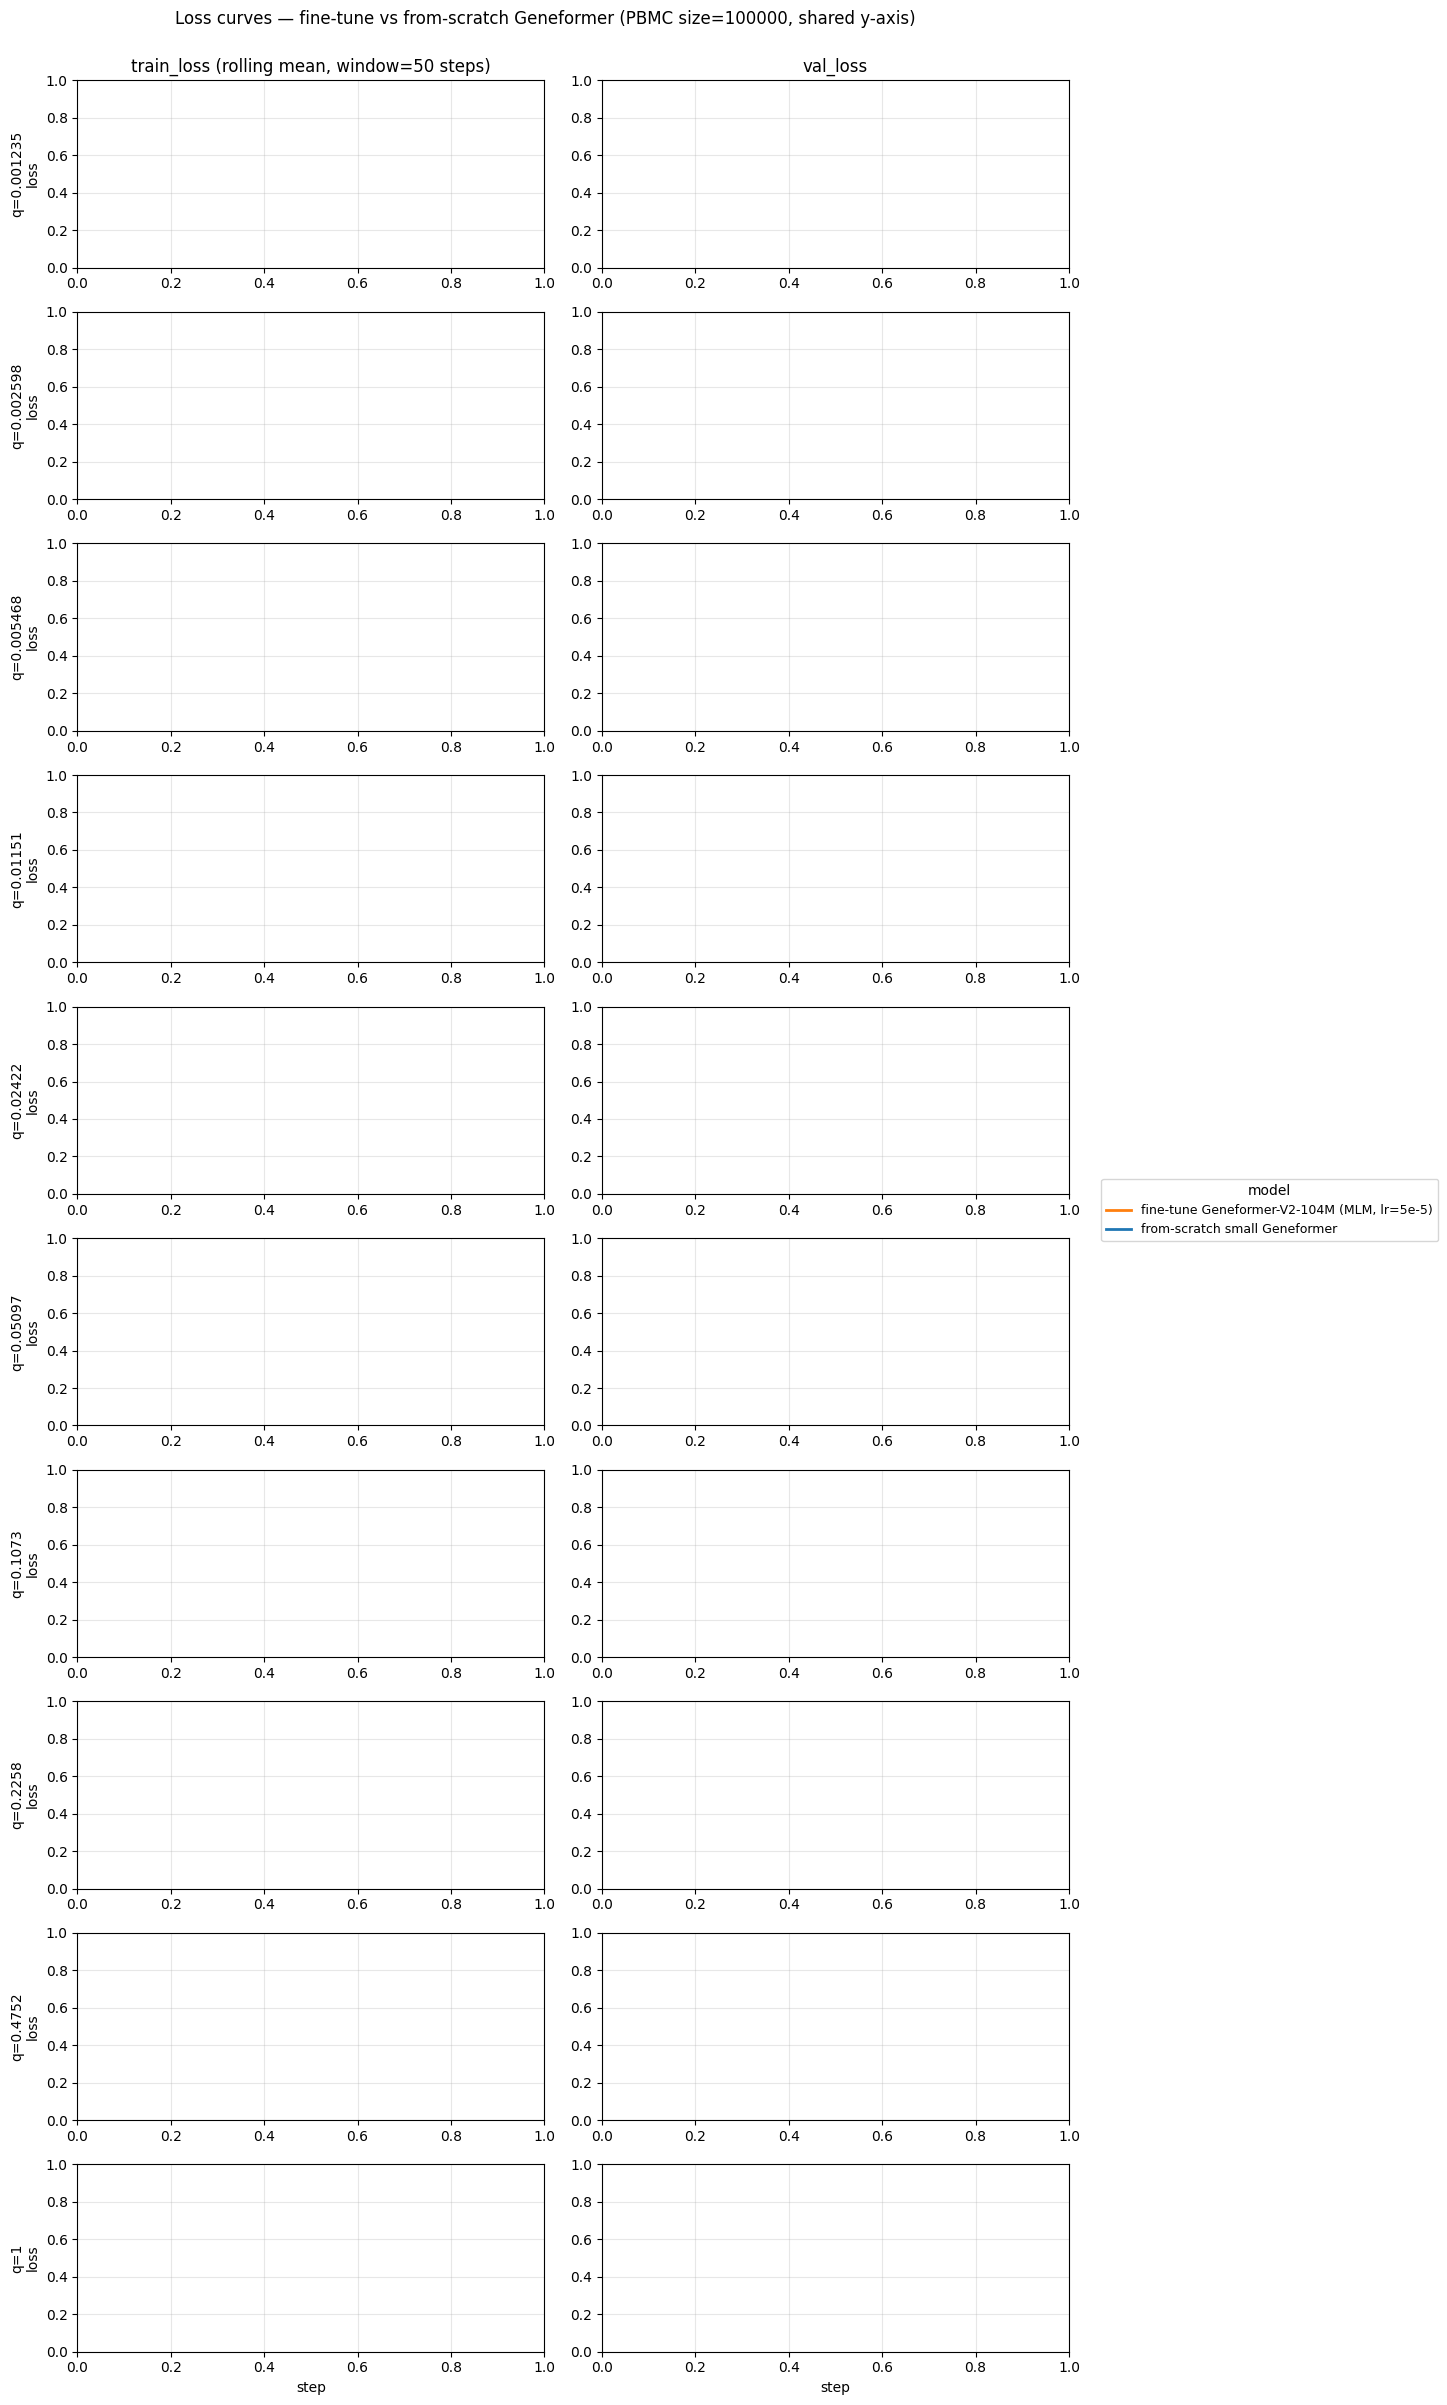

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PLOT_SIZE = max(sizes)
TRAIN_SMOOTH_WINDOW = 50   # HF Trainer logs every 20 steps by default — smooth lightly
SKIP_STEPS = 0

def _smooth(tr):
    if tr is None or not len(tr):
        return tr
    tr = tr[tr['step'] >= SKIP_STEPS].copy()
    if not len(tr):
        return tr
    tr['train_loss'] = tr['train_loss'].rolling(
        window=TRAIN_SMOOTH_WINDOW, min_periods=1, center=True).mean()
    return tr.dropna(subset=['train_loss'])

all_train, all_val = [], []
for quality in qualities_all:
    for store in (CURVES_FT, CURVES_SC):
        tr, va = store.get((PLOT_SIZE, quality), (None, None))
        tr = _smooth(tr)
        if tr is not None and len(tr):
            all_train.append(tr)
        if va is not None and len(va):
            va_clip = va[va['step'] >= SKIP_STEPS]
            if len(va_clip):
                all_val.append(va_clip)

def _pad(lo, hi, frac=0.05):
    lo = float(lo); hi = float(hi); pad = (hi - lo) * frac
    return lo - pad, hi + pad

if all_train:
    train_lo, train_hi = _pad(min(t['train_loss'].min() for t in all_train),
                              max(t['train_loss'].max() for t in all_train))
else:
    train_lo, train_hi = 0.0, 1.0
if all_val:
    val_lo, val_hi = _pad(min(v['val_loss'].min() for v in all_val),
                          max(v['val_loss'].max() for v in all_val))
else:
    val_lo, val_hi = train_lo, train_hi
max_step = max(
    [int(t['step'].iloc[-1]) for t in all_train] + [int(v['step'].iloc[-1]) for v in all_val] or [1],
)

n_rows = len(qualities_all)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.4 * n_rows), squeeze=False)

FT_COLOR, SC_COLOR = 'tab:orange', 'tab:blue'
for r, quality in enumerate(qualities_all):
    ax_tr, ax_va = axes[r, 0], axes[r, 1]
    for store, color, label in [(CURVES_FT, FT_COLOR, 'fine-tune Geneformer-V2-104M'),
                                (CURVES_SC, SC_COLOR, 'from-scratch small Geneformer')]:
        tr, va = store.get((PLOT_SIZE, quality), (None, None))
        tr_s = _smooth(tr)
        if tr_s is not None and len(tr_s):
            ax_tr.plot(tr_s['step'].values, tr_s['train_loss'].values,
                       color=color, linewidth=1.3, alpha=0.9)
        if va is not None and len(va):
            va_c = va[va['step'] >= SKIP_STEPS]
            if len(va_c):
                ax_va.plot(va_c['step'].values, va_c['val_loss'].values,
                           color=color, linewidth=1.3, marker='o', markersize=4)
    ax_tr.set_ylabel(f'q={quality:.4g}\nloss')
    for ax, lo, hi in [(ax_tr, train_lo, train_hi), (ax_va, val_lo, val_hi)]:
        ax.set_xlim(0, max_step)
        ax.set_ylim(lo, hi)
        ax.grid(alpha=0.3)

axes[0, 0].set_title(f'train_loss (rolling mean, window={TRAIN_SMOOTH_WINDOW} steps)')
axes[0, 1].set_title('val_loss')
axes[-1, 0].set_xlabel('step')
axes[-1, 1].set_xlabel('step')

handles = [
    Line2D([0], [0], color=FT_COLOR, linewidth=2, label='fine-tune Geneformer-V2-104M (MLM, lr=5e-5)'),
    Line2D([0], [0], color=SC_COLOR, linewidth=2, label='from-scratch small Geneformer'),
]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, title='model')
fig.suptitle(f'Loss curves — fine-tune vs from-scratch Geneformer (PBMC size={PLOT_SIZE}, shared y-axis)', y=1.0)
plt.tight_layout()
plt.show()

## MI comparison — side-by-side, shared X and Y axes

For each MI signal we plot two panels: from-scratch on the left, fine-tune on the right. Both share X (quality, log) and Y (MI, nats) limits so the curves are directly comparable at a glance. One line per dataset size; the same color encodes the same size across the left/right panels.

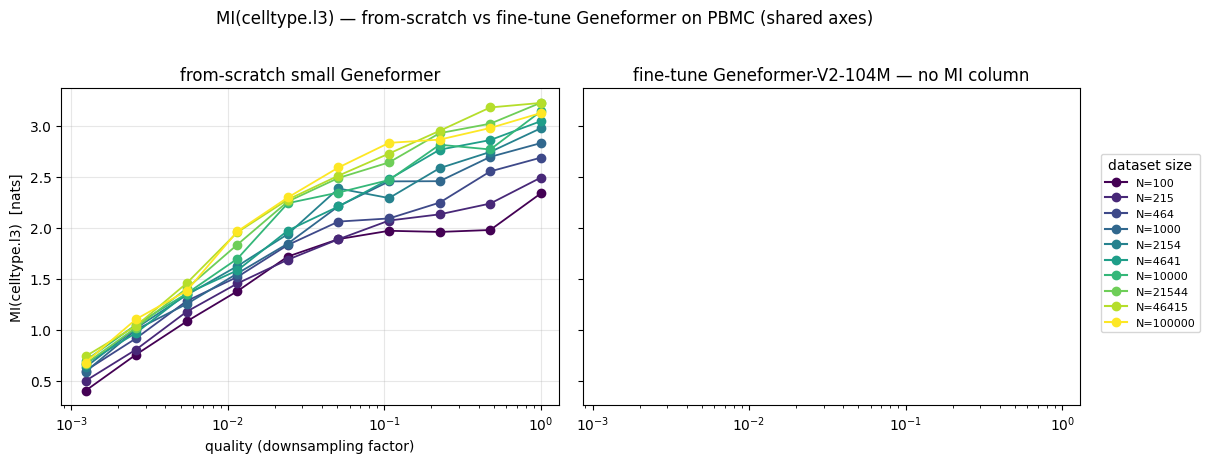

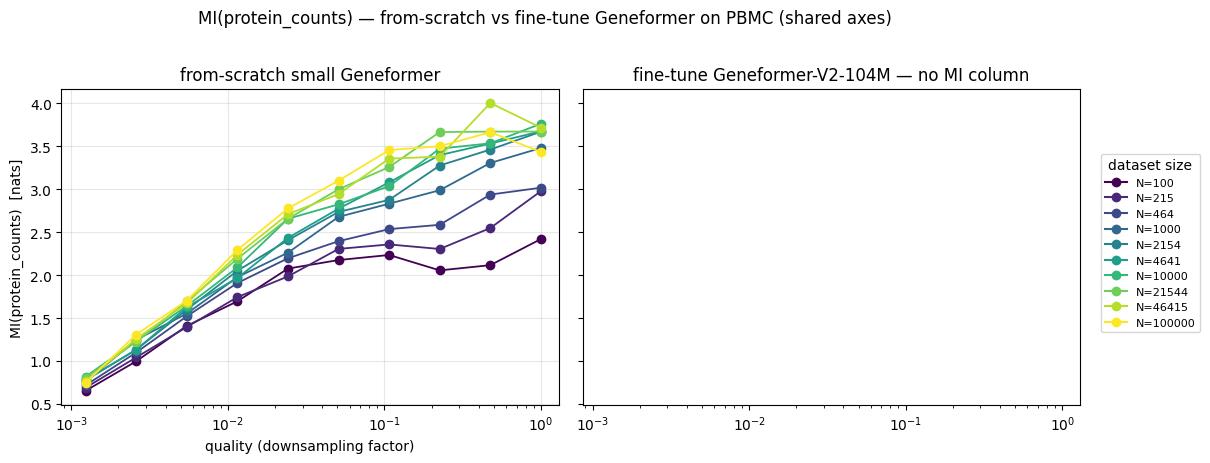

In [4]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.lines import Line2D

size_color = {s: viridis(i / max(1, len(sizes) - 1)) for i, s in enumerate(sizes)}

for signal in mi_signals:
    ft_col, sc_col = f'ft_mi_{signal}', f'sc_mi_{signal}'
    if ft_col not in df.columns and sc_col not in df.columns:
        continue

    y_vals = pd.concat([df[ft_col].dropna() if ft_col in df.columns else pd.Series(dtype=float),
                        df[sc_col].dropna() if sc_col in df.columns else pd.Series(dtype=float)])
    if y_vals.empty:
        print(f'  signal={signal!r}: no MI values on disk yet — skipping.')
        continue
    y_pad = (y_vals.max() - y_vals.min()) * 0.05 or 0.01
    y_lim = (float(y_vals.min()) - y_pad, float(y_vals.max()) + y_pad)
    x_lim = (min(qualities_all) * 0.7, max(qualities_all) * 1.3)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
    for ax, col, title in [(ax_l, sc_col, 'from-scratch small Geneformer'),
                           (ax_r, ft_col, 'fine-tune Geneformer-V2-104M')]:
        if col not in df.columns:
            ax.set_title(f'{title} — no MI column')
            continue
        for size in sizes:
            sub = df[(df['size'] == size) & df[col].notna()].sort_values('quality')
            if sub.empty:
                continue
            ax.plot(sub['quality'].values, sub[col].values,
                    marker='o', color=size_color[size], linewidth=1.3, label=f'N={size}')
        ax.set_xscale('log')
        ax.set_title(title)
        ax.set_xlabel('quality (downsampling factor)')
        ax.grid(alpha=0.3)
        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)
    ax_l.set_ylabel(f'MI({signal})  [nats]')

    handles = [Line2D([0], [0], color=size_color[s], marker='o', label=f'N={s}') for s in sizes]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, title='dataset size')
    fig.suptitle(f'MI({signal}) — from-scratch vs fine-tune Geneformer on PBMC (shared axes)', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.lines import Line2D

# Rows = sizes, columns = [from-scratch, fine-tune], shared x/y axes across the grid.
# All qualities appear on the x-axis of every panel so you can compare sizes down a
# column and scratch-vs-finetune across a row without per-panel rescaling.
quality_color = {q: viridis(i / max(1, len(qualities_all) - 1)) for i, q in enumerate(qualities_all)}

for signal in mi_signals:
    ft_col, sc_col = f'ft_mi_{signal}', f'sc_mi_{signal}'
    if ft_col not in df.columns and sc_col not in df.columns:
        print(f'  signal={signal!r}: no MI columns in df - skipping.')
        continue

    y_vals = pd.concat([df[ft_col].dropna() if ft_col in df.columns else pd.Series(dtype=float),
                        df[sc_col].dropna() if sc_col in df.columns else pd.Series(dtype=float)])
    if y_vals.empty:
        print(f'  signal={signal!r}: no MI values on disk yet - skipping.')
        continue
    y_pad = (y_vals.max() - y_vals.min()) * 0.05 or 0.01
    y_lim = (float(y_vals.min()) - y_pad, float(y_vals.max()) + y_pad)
    x_lim = (min(qualities_all) * 0.7, max(qualities_all) * 1.3)

    n_rows = len(sizes)
    fig, axes = plt.subplots(n_rows, 2, figsize=(11, 3.6 * n_rows),
                             sharex=True, sharey=True, squeeze=False)
    for r, size in enumerate(sizes):
        ax_l, ax_r = axes[r, 0], axes[r, 1]
        for ax, col, title in [(ax_l, sc_col, 'from-scratch small Geneformer'),
                               (ax_r, ft_col, 'fine-tune Geneformer-V2-104M')]:
            if col not in df.columns:
                ax.set_title(f'{title} - no MI column')
                continue
            sub = df[(df['size'] == size) & df[col].notna()].sort_values('quality')
            if not sub.empty:
                # Connect the per-size curve and mark each quality with its own color
                # so the same quality is visually identifiable across sizes and panels.
                ax.plot(sub['quality'].values, sub[col].values,
                        color='0.4', linewidth=1.0, zorder=1)
                ax.scatter(sub['quality'].values, sub[col].values,
                           c=[quality_color[q] for q in sub['quality'].values],
                           s=45, zorder=2, edgecolor='black', linewidth=0.4)
            ax.set_xscale('log')
            ax.set_xlim(*x_lim)
            ax.set_ylim(*y_lim)
            ax.grid(alpha=0.3)
            if r == 0:
                ax.set_title(title)
        ax_l.set_ylabel(f'N={size}\nMI({signal}) [nats]')
    axes[-1, 0].set_xlabel('quality (downsampling factor)')
    axes[-1, 1].set_xlabel('quality (downsampling factor)')

    handles = [Line2D([0], [0], marker='o', linestyle='', color=quality_color[q],
                      markeredgecolor='black', markeredgewidth=0.4, label=f'q={q:.4g}')
               for q in qualities_all]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title='quality')
    fig.suptitle(f'MI({signal}) - from-scratch vs fine-tune Geneformer-V2-104M on PBMC '
                 f'(rows=size, shared axes)', y=1.0)
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Same grid as the previous cell (rows = sizes) but the two regimes are OVERLAID in
# one panel per row instead of split across two columns. Lines overlap directly so
# the scratch-vs-finetune gap at each quality is immediately readable.
SC_COLOR, FT_COLOR = 'tab:blue', 'tab:orange'

for signal in mi_signals:
    ft_col, sc_col = f'ft_mi_{signal}', f'sc_mi_{signal}'
    if ft_col not in df.columns and sc_col not in df.columns:
        print(f'  signal={signal!r}: no MI columns in df - skipping.')
        continue

    y_vals = pd.concat([df[ft_col].dropna() if ft_col in df.columns else pd.Series(dtype=float),
                        df[sc_col].dropna() if sc_col in df.columns else pd.Series(dtype=float)])
    if y_vals.empty:
        print(f'  signal={signal!r}: no MI values on disk yet - skipping.')
        continue
    y_pad = (y_vals.max() - y_vals.min()) * 0.05 or 0.01
    y_lim = (float(y_vals.min()) - y_pad, float(y_vals.max()) + y_pad)
    x_lim = (min(qualities_all) * 0.7, max(qualities_all) * 1.3)

    n_rows = len(sizes)
    fig, axes = plt.subplots(n_rows, 1, figsize=(7, 3.6 * n_rows),
                             sharex=True, sharey=True, squeeze=False)
    for r, size in enumerate(sizes):
        ax = axes[r, 0]
        for col, color, label in [(sc_col, SC_COLOR, 'from-scratch small Geneformer'),
                                  (ft_col, FT_COLOR, 'fine-tune Geneformer-V2-104M')]:
            if col not in df.columns:
                continue
            sub = df[(df['size'] == size) & df[col].notna()].sort_values('quality')
            if sub.empty:
                continue
            ax.plot(sub['quality'].values, sub[col].values,
                    marker='o', color=color, linewidth=1.4, markersize=6, label=label)
        ax.set_xscale('log')
        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)
        ax.grid(alpha=0.3)
        ax.set_ylabel(f'N={size}\nMI({signal}) [nats]')
    axes[-1, 0].set_xlabel('quality (downsampling factor)')

    handles = [Line2D([0], [0], color=SC_COLOR, marker='o', label='from-scratch small Geneformer'),
               Line2D([0], [0], color=FT_COLOR, marker='o', label='fine-tune Geneformer-V2-104M')]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=9, title='model')
    fig.suptitle(f'MI({signal}) - from-scratch vs fine-tune Geneformer-V2-104M on PBMC '
                 f'(rows=size, overlaid, shared axes)', y=1.0)
    plt.tight_layout()
    plt.show()
